<a href="https://colab.research.google.com/github/sohanchelekar276/Summer-of-Quant-2026/blob/main/FinalProjectSoQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install hmmlearn
import yfinance as yf
import pandas as pd
import numpy as np
from hmmlearn import hmm
import warnings
warnings.filterwarnings("ignore")

# 1. Pull the data
# Using NIFTY 50 (^NSEI), India VIX (^INDIAVIX), and Nippon India Gold ETF (GOLDBEES.NS)
tickers = ["^NSEI", "^INDIAVIX", "GOLDBEES.NS"]
print("Downloading market data...")
data = yf.download(tickers, start="2015-01-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()

# 2. Engineer Features
# Calculate daily log returns for the NIFTY 50
data['nifty_ret'] = np.log(data['^NSEI']).diff()

# Volatility feature using a 21-day rolling window (annualized)
data['vol_21d'] = data['nifty_ret'].rolling(21).std() * np.sqrt(252)

data = data.dropna()

# 3. Safely Z-Score using expanding windows
# This ensures we don't leak future data into the past (avoiding lookahead bias)
roll_mean_vol = data['vol_21d'].expanding(min_periods=63).mean()
roll_std_vol = data['vol_21d'].expanding(min_periods=63).std()
data['vol_zscore'] = (data['vol_21d'] - roll_mean_vol) / roll_std_vol

# Apply the same safe z-scoring to the India VIX
roll_mean_vix = data['^INDIAVIX'].expanding(min_periods=63).mean()
roll_std_vix = data['^INDIAVIX'].expanding(min_periods=63).std()
data['vix_zscore'] = (data['^INDIAVIX'] - roll_mean_vix) / roll_std_vix

data = data.dropna()

# 4. Build and Fit the HMM
print("Fitting the Hidden Markov Model...")
# We feed the model our two standardized features: Nifty Volatility and VIX
X = data[['vol_zscore', 'vix_zscore']].values

# Initialize a 3-state model (Bull, Bear, Crisis)
model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=100, random_state=42)
model.fit(X)

# Predict the hidden state for every single day
data['regime'] = model.predict(X)

# 5. Interpret the States
# The HMM just outputs 0, 1, or 2. We must label them by looking at the characteristics.
print("\n--- Regime Characteristics ---")
for i in range(3):
    state_vol = data[data['regime'] == i]['vol_21d'].mean()
    state_vix = data[data['regime'] == i]['^INDIAVIX'].mean()
    print(f"State {i} -> Avg Volatility: {state_vol:.4f} | Avg VIX: {state_vix:.2f}")

Fitting the Hidden Markov Model...

--- Regime Characteristics ---
State 0 -> Avg Volatility: 0.1598 | Avg VIX: 18.90
State 1 -> Avg Volatility: 0.2699 | Avg VIX: 26.31
State 2 -> Avg Volatility: 0.1024 | Avg VIX: 13.64


In [13]:
import cvxpy as cp
import numpy as np
import pandas as pd

def optimize_portfolio(returns_matrix, regime_label):
    """
    Optimizes portfolio weights based on the current regime.
    regime_label: 1 (Crisis), 0 (Bear), 2 (Bull)
    """
    n_assets = returns_matrix.shape[1]

    # Calculate expected returns and covariance matrix from historical window
    mu = returns_matrix.mean().values
    #Sigma = returns_matrix.cov().values
    Sigma = returns_matrix.cov().values + np.eye(n_assets) * 1e-8

    # Define the weights variable we want CVXPY to solve for
    w = cp.Variable(n_assets)

    # Core constraints: Fully invested (sum to 1) and Long-only (no shorting)
    #constraints = [cp.sum(w) == 1, w >= 0]
    constraints = [cp.sum(w) == 1, w >= 0.05, w <= 0.80]

    risk = cp.quad_form(w, cp.psd_wrap(Sigma))

    # Define the objective based on the regime
    if regime_label == 1:
        # CRISIS: Pure risk parity or minimum volatility
        # Objective: Minimize portfolio variance
        #risk = cp.quad_form(w, Sigma)
        objective = cp.Minimize(risk)

    elif regime_label == 2:
        # BULL: Maximize returns while penalizing risk (Max Sharpe proxy)
        # We accept more risk here for higher reward
        risk_aversion = 50.0
        #risk = cp.quad_form(w, Sigma)
        returns = mu @ w
        objective = cp.Maximize(returns - (risk_aversion * risk))

    else:
        # BEAR (State 0): Defensive growth.
        # A higher risk aversion penalty than the Bull state
        risk_aversion = 150.0
        #risk = cp.quad_form(w, Sigma)
        returns = mu @ w
        objective = cp.Maximize(returns - (risk_aversion * risk))

    # Solve the problem
    prob = cp.Problem(objective, constraints)
    try:
        #prob.solve()
        prob.solve(solver=cp.SCS)

        # 3. Explicitly verify the solver succeeded
        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:

            # 4. Paranoia clip: strictly enforce bounds in case of solver tolerance drift
            clean_weights = np.clip(w.value, 0.05, 0.80)
            return clean_weights / clean_weights.sum()

        else:
            return np.ones(n_assets) / n_assets
        #return w.value
    except Exception as e:
        # Fallback to equal weight if the solver fails to find an optimal solution
        return np.ones(n_assets) / n_assets

# 1. Pull the Investable Assets (Stocks, Bonds, Gold)
# ^NSEI (Nifty 50), GOLDBEES.NS (Gold ETF), and let's use a generic Indian G-Sec ETF for bonds
investable_tickers = ["^NSEI", "GOLDBEES.NS", "LICNETFGSC.NS"]
price_data = yf.download(investable_tickers, start="2015-01-01", end="2024-01-01", progress=False)['Close']

# Fill any missing days where one asset traded but another didn't
price_data = price_data.ffill().dropna()

# Pulling VIX for feature engineering (VIX does not split, so 'Close' is fine)
vix_data = yf.download("^INDIAVIX", start="2015-01-01", end="2024-01-01", progress=False)['Close']

# Create multi_asset_returns (The variable needed for the optimizer)
#multi_asset_returns = np.log(price_data).diff().dropna()

# 2. Create feature_data (The variable needed for the HMM)
# Assuming 'data' contains the 'vol_zscore' and 'vix_zscore' you engineered earlier
#feature_data = data[['vol_zscore', 'vix_zscore']].dropna()

# 3. Align the Indices
# This is crucial! If the HMM and the optimizer look at different dates, the code will fail.
#common_dates = multi_asset_returns.index.intersection(feature_data.index)
#multi_asset_returns = multi_asset_returns.loc[common_dates]
#feature_data = feature_data.loc[common_dates]

# Calculating daily log returns
multi_asset_returns = np.log(price_data).diff().dropna()
nifty_ret = multi_asset_returns["^NSEI"]

# Creating rolling window features to prevent lookahead bias
vol_21d = nifty_ret.rolling(21).std() * np.sqrt(252)

feature_data = pd.DataFrame(index=multi_asset_returns.index)

# Switch from expanding() to rolling(252) to keep the signal dynamic
feature_data['vol_zscore'] = (vol_21d - vol_21d.rolling(252).mean()) / vol_21d.rolling(252).std()
feature_data['vix_zscore'] = (vix_data - vix_data.rolling(252).mean()) / vix_data.rolling(252).std()
feature_data = feature_data.dropna()

# Align indices
common_dates = multi_asset_returns.index.intersection(feature_data.index)
multi_asset_returns = multi_asset_returns.loc[common_dates]
feature_data = feature_data.loc[common_dates]

Walk-Forward Engine: 100%|██████████| 1430/1430 [00:44<00:00, 31.83it/s]


--- Dynamic Strategy (GROSS - No Costs) ---
Total Return       442.20%
Ann. Return         34.73%
Ann. Volatility    209.82%
Sharpe Ratio          0.17
Sortino Ratio         0.96
Max Drawdown       -56.32%
Calmar Ratio          0.62
Ann. Turnover      212.86%
dtype: object

--- Dynamic Strategy (NET - With Costs) ---
Total Return       436.16%
Ann. Return         34.47%
Ann. Volatility    209.78%
Sharpe Ratio          0.16
Sortino Ratio         0.95
Max Drawdown       -56.33%
Calmar Ratio          0.61
Ann. Turnover      212.86%
dtype: object

--- Static 60/40 Benchmark ---
Total Return        98.86%
Ann. Return         12.89%
Ann. Volatility     14.36%
Sharpe Ratio           0.9
Sortino Ratio          1.2
Max Drawdown       -26.02%
Calmar Ratio           0.5
Ann. Turnover        0.00%
dtype: object

--- Equal-Weight Benchmark ---
Total Return       4457.14%
Ann. Return          96.11%
Ann. Volatility    1386.23%
Sharpe Ratio           0.07
Sortino Ratio          4.51
Max Drawdown     

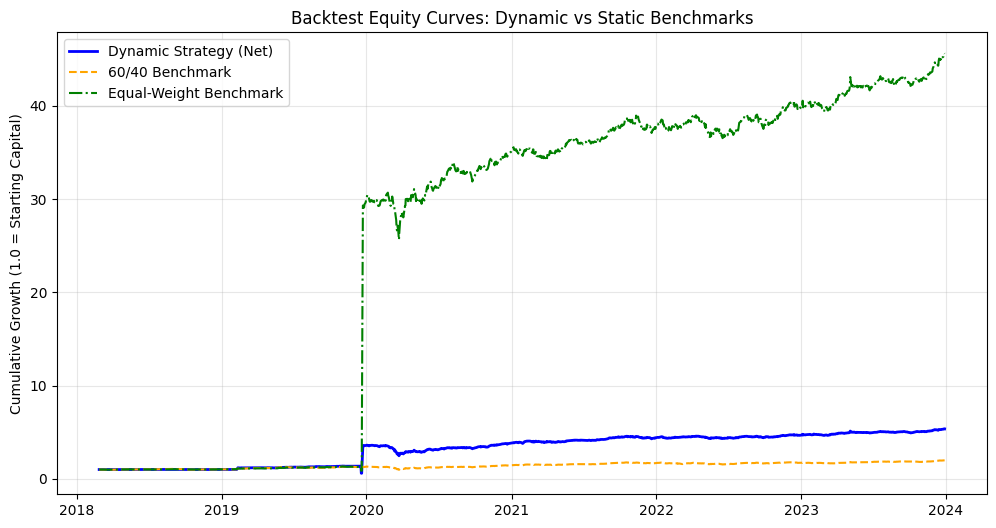

In [14]:
import cvxpy as cp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from hmmlearn import hmm
from tqdm import tqdm

# 1. The Bulletproof Optimizer
def optimize_portfolio(returns_matrix, regime_label):
    n_assets = returns_matrix.shape[1]
    mu = returns_matrix.mean().values

    # Add epsilon to diagonal for strict positive definiteness
    Sigma = returns_matrix.cov().values + np.eye(n_assets) * 1e-8

    w = cp.Variable(n_assets)
    constraints = [cp.sum(w) == 1, w >= 0.05, w <= 0.80]

    # Mathematically promise CVXPY the matrix is safe using psd_wrap
    risk = cp.quad_form(w, cp.psd_wrap(Sigma))

    if regime_label == 1:
        objective = cp.Minimize(risk)
    elif regime_label == 2:
        risk_aversion = 50.0
        objective = cp.Maximize(mu @ w - risk_aversion * risk)
    else:
        risk_aversion = 150.0
        objective = cp.Maximize(mu @ w - risk_aversion * risk)

    prob = cp.Problem(objective, constraints)

    try:
        prob.solve(solver=cp.SCS)
        if prob.status in ["optimal", "optimal_inaccurate"] and w.value is not None:
            clean_weights = np.clip(w.value, 0.05, 0.80)
            return clean_weights / clean_weights.sum()
        else:
            return np.ones(n_assets) / n_assets
    except:
        return np.ones(n_assets) / n_assets

# 2. Reset the weights list to clear old Jupyter memory!
target_weights = []
window_size = 252 * 2

# 3. Walk-Forward Engine
for i in tqdm(range(window_size, len(feature_data)), desc="Walk-Forward Engine"):

    train_features = feature_data.iloc[i - window_size : i]
    train_returns = multi_asset_returns.iloc[i - window_size : i]

    if i % 5 == 0:
        model = hmm.GaussianHMM(n_components=3, covariance_type="full", n_iter=50, random_state=42)
        model.fit(train_features.values)

        state_variances = np.array([np.diag(model.covars_[s])[0] for s in range(3)])
        sorted_states = np.argsort(state_variances)

        bull_state = sorted_states[0]
        bear_state = sorted_states[1]
        crisis_state = sorted_states[2]

    current_day_features = feature_data.iloc[i:i+1].values
    raw_regime = model.predict(current_day_features)[0]

    if raw_regime == crisis_state:
        current_regime = 1
    elif raw_regime == bull_state:
        current_regime = 2
    else:
        current_regime = 0

    optimal_weights = optimize_portfolio(train_returns, current_regime)
    target_weights.append(optimal_weights)

# 4. Backtest Math
test_returns = multi_asset_returns.iloc[window_size:window_size+len(target_weights)]
weights_df = pd.DataFrame(target_weights, index=test_returns.index, columns=test_returns.columns)

implemented_weights = weights_df.shift(1).dropna()
actual_simple_returns = np.exp(test_returns.loc[implemented_weights.index]) - 1

gross_portfolio_returns = (implemented_weights * actual_simple_returns).sum(axis=1)
turnover = implemented_weights.diff().abs().sum(axis=1)
transaction_cost_bps = 0.0010
costs = turnover * transaction_cost_bps

net_portfolio_returns = gross_portfolio_returns - costs
equity_curve = (1 + net_portfolio_returns).cumprod()

# 5. Metrics & Benchmark Calculation
def calculate_metrics(eq_curve, daily_ret, daily_turnover=None):
    total_ret = eq_curve.iloc[-1] - 1
    ann_ret = (1 + total_ret) ** (252 / len(eq_curve)) - 1
    ann_vol = daily_ret.std() * np.sqrt(252)
    sharpe = ann_ret / ann_vol

    # Sortino Ratio (Downside deviation only)
    downside_returns = daily_ret[daily_ret < 0]
    downside_vol = downside_returns.std() * np.sqrt(252)
    sortino = ann_ret / downside_vol if downside_vol > 0 else np.nan

    rolling_max = eq_curve.cummax()
    drawdown = (eq_curve - rolling_max) / rolling_max
    max_dd = drawdown.min()
    calmar = ann_ret / abs(max_dd)

    # Average Annual Turnover
    ann_turnover = daily_turnover.mean() * 252 if daily_turnover is not None else 0

    return pd.Series({
        "Total Return": f"{total_ret * 100:.2f}%",
        "Ann. Return": f"{ann_ret * 100:.2f}%",
        "Ann. Volatility": f"{ann_vol * 100:.2f}%",
        "Sharpe Ratio": round(sharpe, 2),
        "Sortino Ratio": round(sortino, 2),
        "Max Drawdown": f"{max_dd * 100:.2f}%",
        "Calmar Ratio": round(calmar, 2),
        "Ann. Turnover": f"{ann_turnover * 100:.2f}%"
    })

# Dynamically map the benchmark weights to whatever order yfinance alphabetized your columns
bm_weights_dict = {"^NSEI": 0.60, "LICNETFGSC.NS": 0.40, "GOLDBEES.NS": 0.0}
bm_weights_array = np.array([bm_weights_dict.get(col, 0) for col in test_returns.columns])

benchmark_simple_returns = (actual_simple_returns * bm_weights_array).sum(axis=1)
benchmark_equity = (1 + benchmark_simple_returns).cumprod()

# Calculate Equal-Weight Benchmark Returns (33.3% in each asset)
equal_weights = np.ones(3) / 3
ew_simple_returns = (actual_simple_returns * equal_weights).sum(axis=1)
ew_equity = (1 + ew_simple_returns).cumprod()

# Calculate Gross Equity Curve (Without transaction costs)
gross_equity_curve = (1 + gross_portfolio_returns).cumprod()

print("--- Dynamic Strategy (GROSS - No Costs) ---")
print(calculate_metrics(gross_equity_curve, gross_portfolio_returns, turnover))

print("\n--- Dynamic Strategy (NET - With Costs) ---")
print(calculate_metrics(equity_curve, net_portfolio_returns, turnover))

print("\n--- Static 60/40 Benchmark ---")
print(calculate_metrics(benchmark_equity, benchmark_simple_returns))

print("\n--- Equal-Weight Benchmark ---")
print(calculate_metrics(ew_equity, ew_simple_returns))

# Plot the Equity Curves
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(equity_curve.index, equity_curve, label='Dynamic Strategy (Net)', color='blue', lw=2)
ax.plot(benchmark_equity.index, benchmark_equity, label='60/40 Benchmark', color='orange', ls='--')
ax.plot(ew_equity.index, ew_equity, label='Equal-Weight Benchmark', color='green', ls='-.')

plt.title("Backtest Equity Curves: Dynamic vs Static Benchmarks")
plt.ylabel("Cumulative Growth (1.0 = Starting Capital)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

--- HMM Transition Probability Matrix ---
[[0.    1.    0.   ]
 [0.986 0.    0.014]
 [0.    0.005 0.995]]


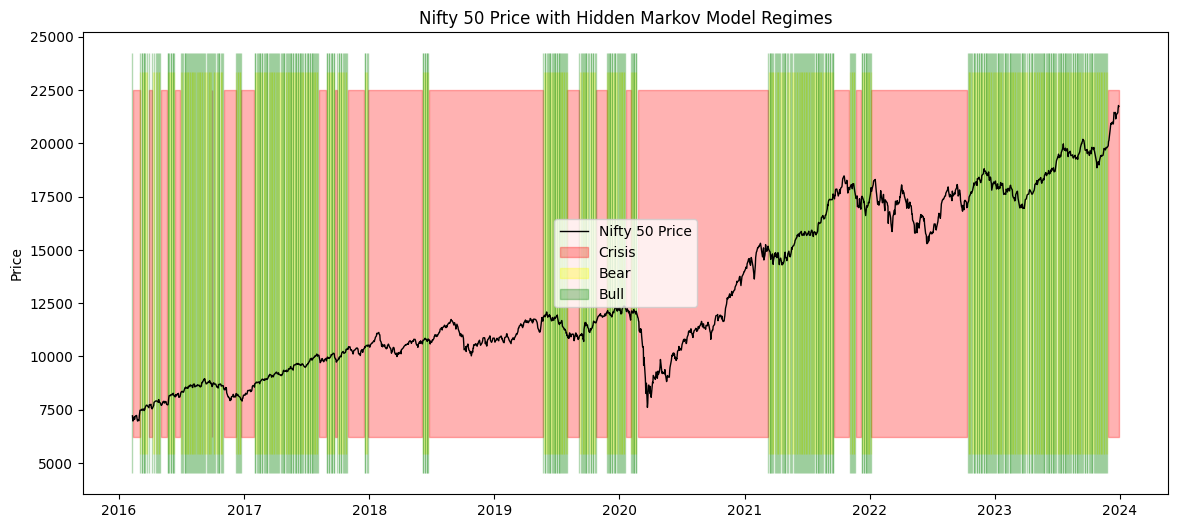

In [15]:
import matplotlib.pyplot as plt

# 1. Print the Transition Matrix
print("--- HMM Transition Probability Matrix ---")
# This shows the likelihood of moving from one state to another (e.g., Bull to Crisis)
print(np.round(model.transmat_, 3))

# 2. Plot Regimes over Price Data
# We will use the final model to predict regimes over the whole feature set for visualization
all_regimes = model.predict(feature_data.values)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(feature_data.index, price_data.loc[feature_data.index, '^NSEI'], color='black', lw=1, label='Nifty 50 Price')

# Shade the background based on the predicted regime
ax.fill_between(feature_data.index, ax.get_ylim()[0], ax.get_ylim()[1],
                where=(all_regimes == crisis_state), color='red', alpha=0.3, label='Crisis')
ax.fill_between(feature_data.index, ax.get_ylim()[0], ax.get_ylim()[1],
                where=(all_regimes == bear_state), color='yellow', alpha=0.3, label='Bear')
ax.fill_between(feature_data.index, ax.get_ylim()[0], ax.get_ylim()[1],
                where=(all_regimes == bull_state), color='green', alpha=0.3, label='Bull')

plt.title("Nifty 50 Price with Hidden Markov Model Regimes")
plt.ylabel("Price")
# Remove duplicate labels in legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())
plt.show()